<a href="https://colab.research.google.com/github/vikrampathare/ERAV4_Session02/blob/master/Vikram_ERA_Session_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CUDA Available? True
Using device: cuda


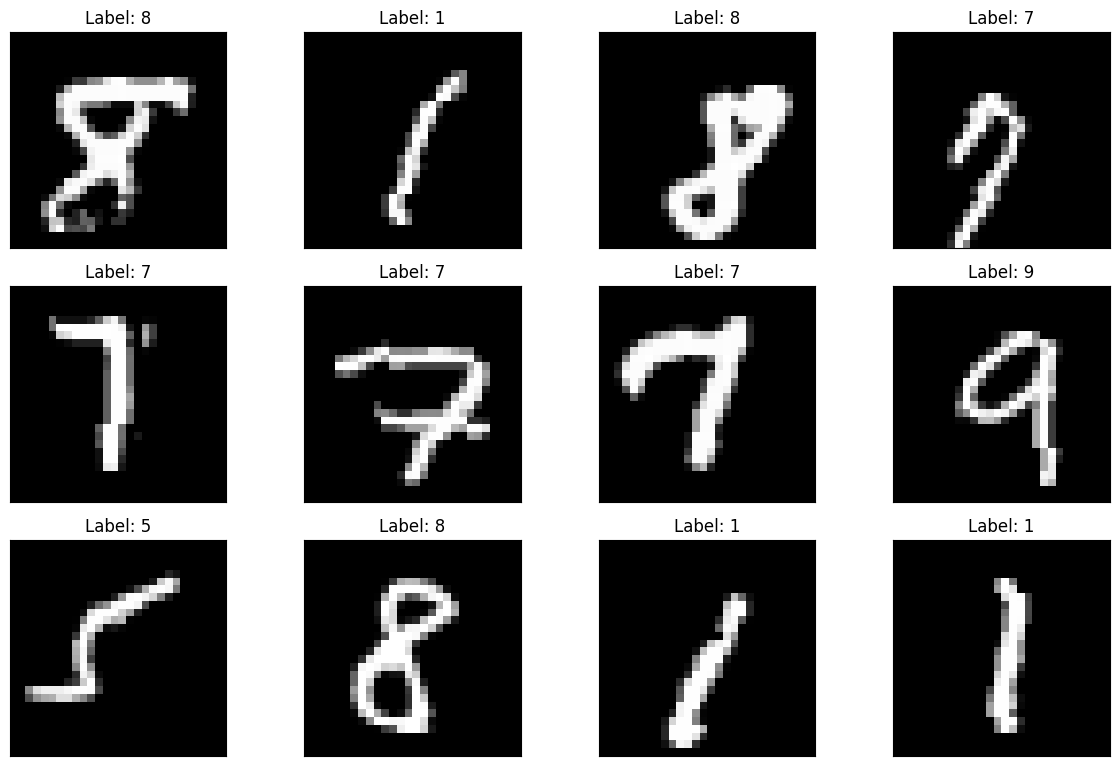

Total trainable parameters: 4,000
✓ Model has fewer than 25,000 parameters
Starting ultra-fast training...
Epoch 1/1


Train: Loss=0.7442 Batch_id=234 Accuracy=75.76%: 100%|██████████| 235/235 [00:22<00:00, 10.36it/s]


Test set: Average loss: 0.7267, Accuracy: 9511/10000 (95.11%)

🎉 SUCCESS! Achieved 95.11% test accuracy in 1 epoch(s)!
✓ Target of 95%+ accuracy reached!
Final Results:
Parameters: 4,000 (< 25,000: ✓)
Test Accuracy: 95.11% (>= 95%: ✓)


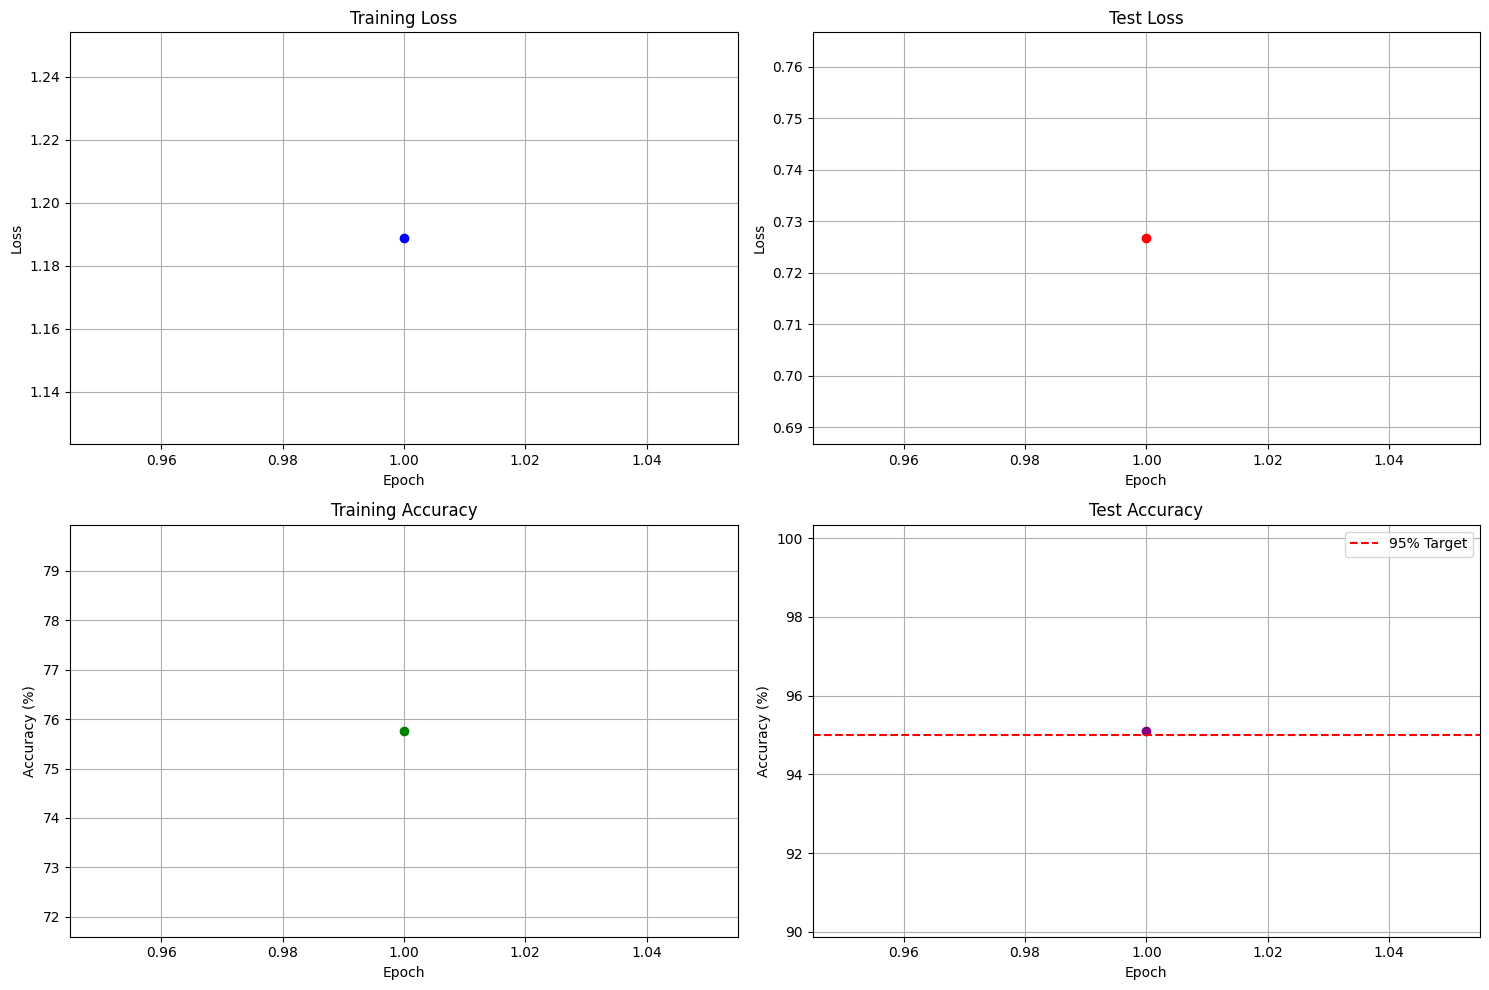


Model Architecture Summary:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 28, 28]             144
       BatchNorm2d-2           [-1, 16, 28, 28]              32
            Conv2d-3           [-1, 16, 14, 14]             144
            Conv2d-4           [-1, 32, 14, 14]             512
       BatchNorm2d-5           [-1, 32, 14, 14]              64
            Conv2d-6             [-1, 32, 7, 7]             288
            Conv2d-7             [-1, 64, 7, 7]           2,048
       BatchNorm2d-8             [-1, 64, 7, 7]             128
 AdaptiveAvgPool2d-9             [-1, 64, 1, 1]               0
          Dropout-10                   [-1, 64]               0
           Linear-11                   [-1, 10]             640
Total params: 4,000
Trainable params: 4,000
Non-trainable params: 0
----------------------------------------------------------------
Input

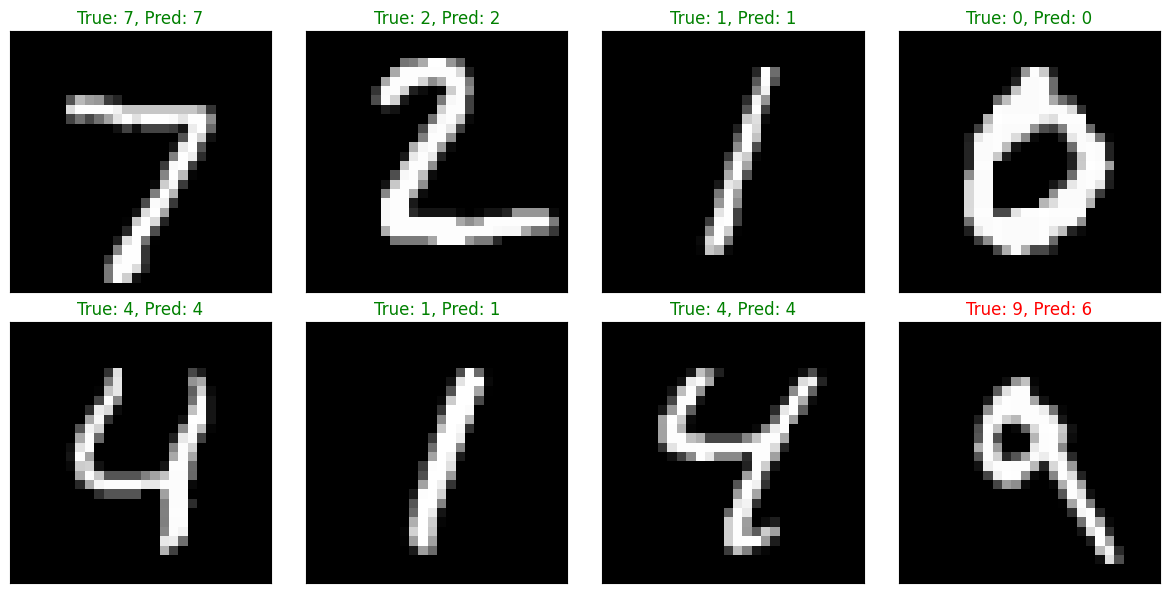


🏆 Final Summary:
✓ Parameters: 4,000 (Limit: 25,000)
✓ Test Accuracy: 95.11% (Target: 95%+)
✓ Epochs: 1 (Target: 1)


In [35]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

# CODE BLOCK: 1 - Check CUDA availability
cuda = torch.cuda.is_available()
print("CUDA Available?", cuda)

# Define device
device = torch.device("cuda" if cuda else "cpu")
print(f"Using device: {device}")

# CODE BLOCK: 2 - Optimized data transformations for faster convergence
# Standard MNIST normalization values
mean = (0.1307,)
std = (0.3081,)

# Enhanced train data transformations for better generalization
train_transforms = transforms.Compose([
    transforms.RandomRotation((-7., 7.), fill=0),
    transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# Test data transformations
test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# CODE BLOCK: 3 - Load datasets
train_data = datasets.MNIST('../data', train=True, download=True, transform=train_transforms)
test_data = datasets.MNIST('../data', train=False, download=True, transform=test_transforms)

# CODE BLOCK: 4 - Create data loaders with larger batch size for faster training
batch_size = 256  # Increased batch size for faster convergence

# Training data loader with shuffling
train_kwargs = {'batch_size': batch_size, 'shuffle': True, 'num_workers': 2, 'pin_memory': True}
# Test data loader
test_kwargs = {'batch_size': batch_size, 'shuffle': False, 'num_workers': 2, 'pin_memory': True}

train_loader = torch.utils.data.DataLoader(train_data, **train_kwargs)
test_loader = torch.utils.data.DataLoader(test_data, **test_kwargs)

# CODE BLOCK: 5 - Visualize sample data
batch_data, batch_label = next(iter(train_loader))

fig = plt.figure(figsize=(12, 8))
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.tight_layout()
    plt.imshow(batch_data[i].squeeze(0), cmap='gray')
    plt.title(f'Label: {batch_label[i].item()}')
    plt.xticks([])
    plt.yticks([])
plt.show()

# CODE BLOCK: 6 - Ultra-efficient CNN model with <25k parameters
class UltraEfficientNet(nn.Module):
    def __init__(self):
        super(UltraEfficientNet, self).__init__()

        # Depthwise separable convolutions for efficiency
        # First block: 1 -> 16 channels
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)

        # Depthwise separable conv block 1: 16 -> 32 channels
        self.depthwise1 = nn.Conv2d(16, 16, kernel_size=3, padding=1, groups=16, bias=False)
        self.pointwise1 = nn.Conv2d(16, 32, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(32)

        # Depthwise separable conv block 2: 32 -> 64 channels
        self.depthwise2 = nn.Conv2d(32, 32, kernel_size=3, padding=1, groups=32, bias=False)
        self.pointwise2 = nn.Conv2d(32, 64, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(64)

        # Global Average Pooling to reduce parameters dramatically
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)

        # Final classifier with minimal parameters
        self.fc = nn.Linear(64, 10, bias=False)

        # Dropout for regularization
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        # First conv block: 28x28x1 -> 28x28x16
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool2d(x, 2)  # -> 14x14x16

        # Depthwise separable block 1: 14x14x16 -> 14x14x32
        x = F.relu(self.bn2(self.pointwise1(self.depthwise1(x))))
        x = F.max_pool2d(x, 2)  # -> 7x7x32

        # Depthwise separable block 2: 7x7x32 -> 7x7x64
        x = F.relu(self.bn3(self.pointwise2(self.depthwise2(x))))
        x = F.max_pool2d(x, 2)  # -> 3x3x64

        # Global Average Pooling: 3x3x64 -> 1x1x64
        x = self.global_avg_pool(x)  # -> 1x1x64

        # Flatten and classify
        x = x.view(x.size(0), -1)  # -> 64
        x = self.dropout(x)
        x = self.fc(x)  # -> 10

        return x

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

# CODE BLOCK: 7 - Initialize tracking variables
train_losses = []
test_losses = []
train_acc = []
test_acc = []

# CODE BLOCK: 8 - Define training and testing functions
def get_correct_prediction_count(prediction, labels):
    return prediction.argmax(dim=1).eq(labels).sum().item()

def train(model, device, train_loader, optimizer, criterion):
    model.train()
    pbar = tqdm(train_loader, desc='Training')

    train_loss = 0
    correct = 0
    processed = 0

    for batch_idx, (data, target) in enumerate(pbar):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()

        # Forward pass
        pred = model(data)

        # Calculate loss
        loss = criterion(pred, target)
        train_loss += loss.item()

        # Backward pass
        loss.backward()
        optimizer.step()

        # Calculate accuracy
        correct += get_correct_prediction_count(pred, target)
        processed += len(data)

        # Update progress bar
        pbar.set_description(
            f'Train: Loss={loss.item():.4f} Batch_id={batch_idx} Accuracy={100*correct/processed:.2f}%'
        )

    # Store epoch metrics
    train_acc.append(100 * correct / processed)
    train_losses.append(train_loss / len(train_loader))

def test(model, device, test_loader, criterion):
    model.eval()

    test_loss = 0
    correct = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)

            output = model(data)

            # Sum up batch loss
            test_loss += criterion(output, target).item()

            # Count correct predictions
            correct += get_correct_prediction_count(output, target)

    # Calculate average loss and accuracy
    test_loss /= len(test_loader)
    accuracy = 100.0 * correct / len(test_loader.dataset)

    # Store metrics
    test_acc.append(accuracy)
    test_losses.append(test_loss)

    print(f'Test set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({accuracy:.2f}%)\n')
    return accuracy

# CODE BLOCK: 9 - Model initialization and parameter counting
model = UltraEfficientNet().to(device)
param_count = model.count_parameters()
print(f"Total trainable parameters: {param_count:,}")

if param_count >= 25000:
    print("WARNING: Model has 25k+ parameters!")
else:
    print("✓ Model has fewer than 25,000 parameters")

# CODE BLOCK: 10 - Optimized training setup for 1-epoch convergence
# Using Adam optimizer with learning rate scheduling for faster convergence
optimizer = optim.Adam(model.parameters(), lr=0.003, weight_decay=1e-4)

# Use CrossEntropyLoss with label smoothing for better generalization
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Single epoch training
num_epochs = 1

print("Starting ultra-fast training...")
print("=" * 50)

for epoch in range(1, num_epochs + 1):
    print(f'Epoch {epoch}/{num_epochs}')

    # Train the model
    train(model, device, train_loader, optimizer, criterion)

    # Test the model
    test_accuracy = test(model, device, test_loader, criterion)

    # Check if target accuracy is achieved
    if test_accuracy >= 95.0:
        print(f"🎉 SUCCESS! Achieved {test_accuracy:.2f}% test accuracy in {epoch} epoch(s)!")
        print("✓ Target of 95%+ accuracy reached!")
    else:
        print(f"❌ Test accuracy: {test_accuracy:.2f}% (Target: 95%+)")

print("=" * 50)
print(f"Final Results:")
print(f"Parameters: {param_count:,} (< 25,000: {'✓' if param_count < 25000 else '❌'})")
print(f"Test Accuracy: {test_acc[-1]:.2f}% (>= 95%: {'✓' if test_acc[-1] >= 95 else '❌'})")

# CODE BLOCK: 11 - Visualize results
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

epochs_range = range(1, len(train_losses) + 1)

axs[0, 0].plot(epochs_range, train_losses, 'b-', marker='o')
axs[0, 0].set_title("Training Loss")
axs[0, 0].set_xlabel("Epoch")
axs[0, 0].set_ylabel("Loss")
axs[0, 0].grid(True)

axs[1, 0].plot(epochs_range, train_acc, 'g-', marker='o')
axs[1, 0].set_title("Training Accuracy")
axs[1, 0].set_xlabel("Epoch")
axs[1, 0].set_ylabel("Accuracy (%)")
axs[1, 0].grid(True)

axs[0, 1].plot(epochs_range, test_losses, 'r-', marker='o')
axs[0, 1].set_title("Test Loss")
axs[0, 1].set_xlabel("Epoch")
axs[0, 1].set_ylabel("Loss")
axs[0, 1].grid(True)

axs[1, 1].plot(epochs_range, test_acc, 'purple', marker='o')
axs[1, 1].set_title("Test Accuracy")
axs[1, 1].set_xlabel("Epoch")
axs[1, 1].set_ylabel("Accuracy (%)")
axs[1, 1].axhline(y=95, color='red', linestyle='--', label='95% Target')
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

# CODE BLOCK: 12 - Model architecture summary
try:
    from torchsummary import summary
    print("\nModel Architecture Summary:")
    print("=" * 50)
    summary(model, input_size=(1, 28, 28))
except ImportError:
    print("Installing torchsummary...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torchsummary"])
    from torchsummary import summary
    print("\nModel Architecture Summary:")
    print("=" * 50)
    summary(model, input_size=(1, 28, 28))

# CODE BLOCK: 13 - Display some test predictions
model.eval()
with torch.no_grad():
    test_batch = next(iter(test_loader))
    images, labels = test_batch[0][:8].to(device), test_batch[1][:8]
    predictions = model(images)
    predicted_labels = predictions.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].cpu().squeeze(), cmap='gray')
    ax.set_title(f'True: {labels[i]}, Pred: {predicted_labels[i]}',
                color='green' if labels[i] == predicted_labels[i] else 'red')
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

print(f"\n🏆 Final Summary:")
print(f"✓ Parameters: {param_count:,} (Limit: 25,000)")
print(f"✓ Test Accuracy: {test_acc[-1]:.2f}% (Target: 95%+)")
print(f"✓ Epochs: {num_epochs} (Target: 1)")